# Relatório de Modelagem

**Universidade Estadual de Montes Claros**  
**Especialização em Ciência de Dados**  
**Disciplina:** Projeto Integrado em Ciência de Dados  
**Docente:** Dra. Luciana Balieiro Cosme  
**Alunos:**
*  Luan Silva Gomes
*  Mateus Nobre Silva Almeida
*  Paulo Matheus Mendes  

**Projeto:** Predizer o desempenho em Língua Portuguesa e Matemática, do 5º e 9º ano do Ensino Fundamental, das escolas Estaduais e Municipais do estado de Minas Gerais, utilizando a série histórica de 2015-2025 disponível no Portal das Avaliações Educacionais de Minas Gerais, para que Instituições e pessoas interessadas possam tomar medidas e criar políticas com maior eficiência a fim de melhorar esses indicadores.

**Objetivo:** Neste trabalho serão desenvolvidos e avaliados modelos de classificação utilizando os dados educacionais do SIMAVE. O processo será dividido em preparação dos dados, criação de um modelo inicial, realização de experimentos, escolha do modelo final, análise dos erros e apresentação das limitações encontradas.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ_PROJETO = next(
    (pasta for pasta in [Path.cwd(), *Path.cwd().parents] if (pasta / "src").exists()),
    Path.cwd(),
)
if str(RAIZ_PROJETO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROJETO))

from src.modelagem import (
    ANOS_MODELAGEM,
    avaliar_validacao_cruzada,
    carregar_bases_descritores,
    criar_pipeline_arvore_decisao,
    criar_pipeline_modelo_final,
    criar_pipeline_regressao_logistica,
    criar_preprocessador,
    criar_variavel_alvo,
    filtrar_publico_modelagem,
    limpar_percentual_acerto,
    salvar_modelo,
    selecionar_conteudos,
    selecionar_conteudos_amplo,
    separar_treino_teste,
    treinar_modelo_final,
)


## 1. Preparação dos dados

Nesta etapa, as bases dos diferentes anos serão carregadas e organizadas em um único conjunto de dados. Também serão realizados os tratamentos necessários para deixar as informações prontas para a criação e avaliação dos modelos de classificação.

In [2]:
anos = list(ANOS_MODELAGEM)

### Carregamento e união das bases

As bases dos anos selecionados foram carregadas individualmente e, em seguida, reunidas em um único conjunto de dados. Para reduzir o tamanho da base e facilitar a etapa de modelagem, foram mantidas apenas as variáveis que poderão ser utilizadas na construção e avaliação dos modelos.

In [4]:
caminho_dados = RAIZ_PROJETO / "data" / "raw"

dados = carregar_bases_descritores(
    diretorio=caminho_dados,
    anos=anos,
)

print("Bases carregadas com sucesso!")
print("Quantidade de registros:", dados.shape[0])
print("Quantidade de variáveis:", dados.shape[1])

Bases carregadas com sucesso!
Quantidade de registros: 5569759
Quantidade de variáveis: 7


###### Verificação inicial dos dados

Após a união das bases, foi realizada uma verificação inicial para observar a estrutura do conjunto de dados, os tipos das variáveis e alguns exemplos dos registros carregados.

In [5]:
dados.head()

,Ano,rede,etapa,disciplina,descritor_nome,descritor_descricao,acerto
0,2015,ESTADUAL,7º ANO EF,LINGUA PORTUGUESA,D01,IDENTIFICAR O TEMA OU O SENTIDO GLOBAL DE UM T...,65
1,2015,ESTADUAL,7º ANO EF,LINGUA PORTUGUESA,D02,LOCALIZAR INFORMACOES EXPLICITAS EM UM TEXTO,70
2,2015,ESTADUAL,7º ANO EF,LINGUA PORTUGUESA,D03,INFERIR INFORMACOES EM UM TEXTO,61
3,2015,ESTADUAL,7º ANO EF,LINGUA PORTUGUESA,D04,INFERIR O SENTIDO DE UMA PALAVRA OU EXPRESSAO ...,64
4,2015,ESTADUAL,7º ANO EF,LINGUA PORTUGUESA,D05,DISTINGUIR UM FATO DE UMA OPINIAO EM UM TEXTO,46


In [6]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5569759 entries, 0 to 5569758
Data columns (total 7 columns):
 #   Column               Dtype 
---  ------               ----- 
 0   Ano                  int64 
 1   rede                 object
 2   etapa                object
 3   disciplina           object
 4   descritor_nome       object
 5   descritor_descricao  object
 6   acerto               object
dtypes: int64(1), object(6)
memory usage: 297.5+ MB


### Verificação das etapas e disciplinas

Antes da aplicação dos filtros, foram verificados os nomes utilizados nas bases para representar as etapas de ensino e as disciplinas. Essa conferência evita a perda de registros causada por diferenças na escrita das categorias.

In [7]:
dados["etapa"].value_counts()

etapa
5º ANO EF    1432536
9º ANO EF    1420761
3º ANO EM    1017357
2º ANO EF     842112
3º ANO EF     449617
7º ANO EF     287584
1º ANO EM     119758
Name: count, dtype: int64

In [8]:
dados["disciplina"].value_counts()

disciplina
MATEMATICA           2734768
LINGUA PORTUGUESA    1996319
Matemática            549722
Língua Portuguesa     278402
ESCRITA                10514
Name: count, dtype: int64

### Padronização e seleção dos dados

Foram padronizados os nomes das etapas, disciplinas e redes de ensino para evitar que diferenças de letras maiúsculas, minúsculas, acentuação ou variações de escrita fossem consideradas como categorias diferentes. Em seguida, foram selecionados os registros das redes municipal e estadual referentes ao 5º e ao 9º ano do Ensino Fundamental, nas disciplinas de Matemática e Língua Portuguesa.


In [9]:
dados_filtrados = filtrar_publico_modelagem(dados)

print("Quantidade antes do filtro:", dados.shape[0])
print("Quantidade depois do filtro:", dados_filtrados.shape[0])
print("\nRegistros por rede após o filtro:")
print(dados_filtrados["rede"].value_counts(dropna=False))


Quantidade antes do filtro: 5569759
Quantidade depois do filtro: 2853297

Registros por rede após o filtro:
rede
MUNICIPAL    1459757
ESTADUAL     1393540
Name: count, dtype: int64


### Seleção dos conteúdos avaliados

Para a modelagem, foram selecionados conteúdos considerados importantes para a aprendizagem no 5º e no 9º ano do Ensino Fundamental. Em Língua Portuguesa, foram priorizadas habilidades relacionadas à leitura e interpretação de textos. Em Matemática, foram considerados conteúdos envolvendo operações, números racionais, frações, porcentagem, proporcionalidade e interpretação de tabelas e gráficos.

In [10]:
dados_conteudos = selecionar_conteudos_amplo(dados_filtrados)

print("Registros antes da seleção:", dados_filtrados.shape[0])
print("Registros após a seleção:", dados_conteudos.shape[0])


Registros antes da seleção: 2853297
Registros após a seleção: 1247246


### Conferência dos conteúdos selecionados

Após a aplicação do filtro, foi realizada uma conferência dos descritores selecionados. Essa etapa permite verificar se os conteúdos encontrados correspondem às habilidades definidas para o estudo.

In [11]:

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", None)


descritores_selecionados = (
    dados_conteudos[
        [
            "disciplina",
            "descritor_nome",
            "descritor_descricao"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "disciplina",
            "descritor_nome"
        ]
    )
    .reset_index(drop=True)
)

descritores_selecionados

,disciplina,descritor_nome,descritor_descricao
0,LINGUA PORTUGUESA,D01,IDENTIFICAR O TEMA OU O SENTIDO GLOBAL DE UM TEXTO
1,LINGUA PORTUGUESA,D01,Localizar informações explícitas em um texto.
2,LINGUA PORTUGUESA,D02,LOCALIZAR INFORMACOES EXPLICITAS EM UM TEXTO
3,LINGUA PORTUGUESA,D03,INFERIR INFORMACOES EM UM TEXTO
4,LINGUA PORTUGUESA,D03,Inferir o sentido de uma palavra ou expressão.
5,LINGUA PORTUGUESA,D04,INFERIR O SENTIDO DE UMA PALAVRA OU EXPRESSAO EM UM TEXTO
6,LINGUA PORTUGUESA,D04,Inferir uma informação implícita em um texto.
7,LINGUA PORTUGUESA,D05,DISTINGUIR UM FATO DE UMA OPINIAO EM UM TEXTO
8,LINGUA PORTUGUESA,D05,"Interpretar texto com auxílio de material gráfico diverso (propagandas, quadrinhos, foto, etc.)."
9,LINGUA PORTUGUESA,D06,Identificar o tema de um texto.


In [12]:
dados_conteudos = selecionar_conteudos(dados_filtrados)

print("Registros selecionados:", dados_conteudos.shape[0])


Registros selecionados: 833574


In [13]:
descritores_selecionados = (
    dados_conteudos[
        [
            "disciplina",
            "descritor_nome",
            "descritor_descricao"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "disciplina",
            "descritor_nome"
        ]
    )
    .reset_index(drop=True)
)

descritores_selecionados

,disciplina,descritor_nome,descritor_descricao
0,LINGUA PORTUGUESA,D01,IDENTIFICAR O TEMA OU O SENTIDO GLOBAL DE UM TEXTO
1,LINGUA PORTUGUESA,D01,Localizar informações explícitas em um texto.
2,LINGUA PORTUGUESA,D02,LOCALIZAR INFORMACOES EXPLICITAS EM UM TEXTO
3,LINGUA PORTUGUESA,D03,INFERIR INFORMACOES EM UM TEXTO
4,LINGUA PORTUGUESA,D03,Inferir o sentido de uma palavra ou expressão.
5,LINGUA PORTUGUESA,D04,INFERIR O SENTIDO DE UMA PALAVRA OU EXPRESSAO EM UM TEXTO
6,LINGUA PORTUGUESA,D04,Inferir uma informação implícita em um texto.
7,LINGUA PORTUGUESA,D05,DISTINGUIR UM FATO DE UMA OPINIAO EM UM TEXTO
8,LINGUA PORTUGUESA,D06,Identificar o tema de um texto.
9,LINGUA PORTUGUESA,D11,Distinguir um fato da opinião relativa a esse fato.


### Verificação da variável de desempenho

A variável “acerto” representa o percentual obtido em cada descritor e será utilizada na criação da variável alvo do modelo. Antes da modelagem, foram verificados os valores numéricos, os dados ausentes e os códigos especiais, como BP e NP.

In [14]:

acerto_texto = (
    dados_conteudos["acerto"]
    .astype(str)
    .str.strip()
    .str.upper()
)

acerto_numerico = pd.to_numeric(
    dados_conteudos["acerto"]
    .astype(str)
    .str.replace(",", ".", regex=False),
    errors="coerce"
)

resumo_acerto = pd.DataFrame({
    
    "Situação": [
        "Valores numéricos válidos",
        "Valores ausentes",
        "Código BP",
        "Código NP"
    ],
    
    "Quantidade": [
        acerto_numerico.notna().sum(),
        dados_conteudos["acerto"].isna().sum(),
        (acerto_texto == "BP").sum(),
        (acerto_texto == "NP").sum()
    ]
})

resumo_acerto

,Situação,Quantidade
0,Valores numéricos válidos,697617
1,Valores ausentes,1258
2,Código BP,92194
3,Código NP,29992


### Verificação de outros valores não numéricos

Além dos valores ausentes e dos códigos BP e NP, foi realizada uma verificação para identificar possíveis valores diferentes que não puderam ser convertidos para formato numérico.

In [15]:

outros_valores = (
    dados_conteudos.loc[
        acerto_numerico.isna(),
        "acerto"
    ]
    .astype("string")
    .str.strip()
    .str.upper()
    .fillna("AUSENTE")
    .value_counts()
)

outros_valores.head(20)

acerto
BP         92194
NP         29992
NP/BP       7113
-           5400
AUSENTE     1258
Name: count, dtype: Int64


A verificação identificou registros com os códigos BP, NP e NP/BP, além de valores representados por hífen e campos sem preenchimento. Como esses casos não apresentam um percentual de acerto válido, eles foram removidos da etapa de modelagem.

Após o tratamento, foram mantidos somente os registros que possuíam valores numéricos na variável “acerto”.

In [16]:
registros_antes = dados_conteudos.shape[0]
dados_modelagem = limpar_percentual_acerto(dados_conteudos)
registros_depois = dados_modelagem.shape[0]

print("Registros antes da limpeza:", registros_antes)
print("Registros removidos:", registros_antes - registros_depois)
print("Registros após a limpeza:", registros_depois)


Registros antes da limpeza: 833574
Registros removidos: 135957
Registros após a limpeza: 697617


### Verificação dos valores de acerto

Após a remoção dos registros sem percentual válido, foi realizada uma verificação dos valores mínimos, máximos e das principais medidas estatísticas da variável “acerto”. Essa etapa permite identificar possíveis valores fora do intervalo esperado antes da criação da variável alvo.

In [17]:

dados_modelagem["acerto"].describe()

count     697617.0
mean      56.15289
std      21.742006
min            0.0
25%           42.0
50%           57.0
75%           71.0
max          100.0
Name: acerto, dtype: Float64

In [18]:
valores_invalidos = dados_modelagem[
    (dados_modelagem["acerto"] < 0) |
    (dados_modelagem["acerto"] > 100)
]

print(
    "Quantidade de valores fora do intervalo:",
    valores_invalidos.shape[0]
)

Quantidade de valores fora do intervalo: 0


### Resumo da preparação dos dados

As bases dos anos selecionados foram reunidas e filtradas de acordo com o objetivo do estudo. Foram mantidos os registros das redes municipal e estadual referentes ao 5º e ao 9º ano do Ensino Fundamental, nas disciplinas de Matemática e Língua Portuguesa.

Também foram selecionados conteúdos considerados importantes para a aprendizagem e removidos os registros que não apresentavam percentual de acerto válido. Após o tratamento, a base utilizada na modelagem passou a possuir 697.617 registros.

Com os dados organizados e verificados, a próxima etapa consiste na criação da variável alvo e na separação dos conjuntos de treino e teste.


## Criação da variável alvo

Para realizar a classificação, foi criada uma variável alvo com base na mediana do percentual de acerto. Os registros com desempenho abaixo da mediana foram classificados como prioridade de atenção, enquanto os resultados iguais ou superiores à mediana foram considerados como desempenho acima do ponto de referência utilizado.

Esse limite foi adotado como critério estatístico para a modelagem e não representa uma classificação pedagógica oficial.

In [19]:
dados_modelagem, limite_acerto = criar_variavel_alvo(dados_modelagem)

print("Mediana do percentual de acerto:", limite_acerto)

# Significado das classes:
# 0 = desempenho igual ou acima da mediana
# 1 = desempenho abaixo da mediana


Mediana do percentual de acerto: 57.0


In [20]:

distribuicao_alvo = (
    dados_modelagem["alvo"]
    .value_counts()
    .sort_index()
)

distribuicao_alvo

alvo
0    357908
1    339709
Name: count, dtype: int64

In [21]:

(
    dados_modelagem["alvo"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

alvo
0    51.3
1    48.7
Name: proportion, dtype: float64

### Interpretação da variável alvo

A mediana do percentual de acerto foi de 57%. A partir desse valor, os registros foram divididos em duas classes: desempenho igual ou acima da mediana e desempenho abaixo da mediana.

As classes apresentaram proporções próximas, com 51.3% dos registros na classe 0 e 48.7% na classe 1. Dessa forma, não foi necessário realizar procedimentos adicionais de balanceamento dos dados.

## Separação dos dados em treino e teste

Para avaliar o desempenho dos modelos, a base foi dividida em dois conjuntos. Foram utilizados 80% dos registros para treinamento e 20% para teste.

O conjunto de treinamento será utilizado para que os modelos identifiquem padrões nos dados. Já o conjunto de teste será utilizado apenas na avaliação final, permitindo verificar o desempenho do modelo em registros que não foram utilizados durante o treinamento.

In [22]:
X_treino, X_teste, y_treino, y_teste = separar_treino_teste(
    dados_modelagem,
    tamanho_teste=0.20,
    semente=42,
)

print("Registros utilizados no treinamento:", X_treino.shape[0])
print("Registros utilizados no teste:", X_teste.shape[0])


Registros utilizados no treinamento: 558093
Registros utilizados no teste: 139524


# Seção 1 — Modelo Baseline

O modelo baseline foi utilizado como ponto inicial de comparação. Para essa etapa, foi utilizado o `DummyClassifier`, que realiza previsões utilizando uma estratégia simples, sem identificar relações entre as características dos dados.

Foi escolhida a estratégia de prever sempre a classe mais frequente no conjunto de treinamento. Dessa forma, o resultado obtido representa um desempenho mínimo que os modelos testados posteriormente deverão superar.

In [23]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score


modelo_baseline = DummyClassifier(
    strategy="most_frequent"
)

modelo_baseline.fit(
    X_treino,
    y_treino
)

previsoes_baseline = modelo_baseline.predict(
    X_teste
)

acuracia_baseline = accuracy_score(
    y_teste,
    previsoes_baseline
)

acuracia_balanceada_baseline = balanced_accuracy_score(
    y_teste,
    previsoes_baseline
)

print(
    "Acurácia do baseline:",
    round(acuracia_baseline * 100, 2),
    "%"
)

print(
    "Acurácia balanceada:",
    round(acuracia_balanceada_baseline * 100, 2),
    "%"
)

Acurácia do baseline: 51.3 %
Acurácia balanceada: 50.0 %


# Seção 2 — Experimentos

Nesta seção serão avaliados diferentes modelos de classificação. Para comparar os resultados, será utilizada a validação cruzada, permitindo observar tanto o desempenho médio quanto a variação dos resultados entre diferentes divisões dos dados.

Como as variáveis rede, etapa, disciplina e descritor são categóricas, foi utilizada a técnica One-Hot Encoding para convertê-las em informações numéricas sem criar uma relação de ordem entre as categorias.


In [24]:
preprocessador = criar_preprocessador()

print("Preparação dos experimentos concluída!")


Preparação dos experimentos concluída!


## Experimento 1 — Regressão Logística

A Regressão Logística foi escolhida como primeiro modelo por ser uma abordagem simples, rápida e fácil de interpretar. Apesar do nome, ela é utilizada em problemas de classificação e calcula a probabilidade de cada registro pertencer a uma das classes.

O modelo foi configurado com até 1.000 iterações. Seu desempenho foi avaliado por meio de validação cruzada com três divisões, utilizando a acurácia balanceada como métrica.

In [25]:
pipeline_logistica = criar_pipeline_regressao_logistica()
validacao_logistica = avaliar_validacao_cruzada(
    pipeline_logistica,
    X_treino,
    y_treino,
)
resultado_logistica = validacao_logistica.pontuacoes
media_logistica = validacao_logistica.media
desvio_logistica = validacao_logistica.desvio_padrao

print("Resultados de cada divisão:", resultado_logistica.round(4))
print("Média da acurácia balanceada:", round(media_logistica * 100, 2), "%")
print("Desvio padrão:", round(desvio_logistica * 100, 2), "%")


/Users/luangomes/Code/projeto-integrado-simave-mg/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/luangomes/Code/projeto-integrado-simave-mg/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as

Resultados de cada divisão: [0.7399 0.7394 0.7403]
Média da acurácia balanceada: 73.99 %
Desvio padrão: 0.04 %


/Users/luangomes/Code/projeto-integrado-simave-mg/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Interpretação da Regressão Logística

A Regressão Logística apresentou acurácia balanceada média de 73,99%, superando o resultado obtido pelo modelo baseline. Isso indica que o modelo conseguiu identificar relações entre as características dos registros e as classes de desempenho.

O desvio padrão foi de apenas 0,04%, mostrando que os resultados permaneceram semelhantes nas três divisões da validação cruzada. Dessa forma, o modelo apresentou desempenho estável e superior ao modelo utilizado como referência.

## Experimento 2 — Árvore de Decisão

A Árvore de Decisão foi escolhida por ser um modelo capaz de identificar relações mais complexas entre as características dos dados. Seu funcionamento ocorre por meio da criação de regras sucessivas que dividem os registros de acordo com as informações disponíveis.

Para reduzir o risco de o modelo memorizar excessivamente os dados de treinamento, foi limitada a profundidade máxima da árvore e definida uma quantidade mínima de registros em cada folha. O desempenho foi avaliado utilizando a mesma validação cruzada e a mesma métrica aplicada no experimento anterior.

In [26]:
pipeline_arvore = criar_pipeline_arvore_decisao()
validacao_arvore = avaliar_validacao_cruzada(
    pipeline_arvore,
    X_treino,
    y_treino,
)
resultado_arvore = validacao_arvore.pontuacoes
media_arvore = validacao_arvore.media
desvio_arvore = validacao_arvore.desvio_padrao

print("Resultados de cada divisão:", resultado_arvore.round(4))
print("Média da acurácia balanceada:", round(media_arvore * 100, 2), "%")
print("Desvio padrão:", round(desvio_arvore * 100, 2), "%")


Resultados de cada divisão: [0.7403 0.741  0.7332]
Média da acurácia balanceada: 73.82 %
Desvio padrão: 0.35 %


### Interpretação da Árvore de Decisão

A Árvore de Decisão apresentou acurácia balanceada média de 73,82%, resultado muito próximo ao obtido pela Regressão Logística. A diferença entre os dois modelos foi de apenas 0,17.

O desvio padrão foi de 0,35%, indicando que o desempenho apresentou uma pequena variação entre as divisões da validação cruzada. Mesmo assim, o modelo permaneceu estável e superou com folga o resultado do baseline.

## Experimento 3 — Random Forest

A Random Forest combina várias árvores de decisão para realizar as classificações. Cada árvore analisa diferentes partes dos dados e, ao final, o resultado é definido pela combinação das previsões realizadas.

Essa abordagem pode reduzir alguns erros encontrados em uma única árvore e melhorar a capacidade de identificar padrões mais complexos. Para evitar um processamento excessivo, foram utilizadas 100 árvores com profundidade máxima limitada.

In [27]:
pipeline_random_forest = criar_pipeline_modelo_final()
validacao_random_forest = avaliar_validacao_cruzada(
    pipeline_random_forest,
    X_treino,
    y_treino,
)
resultado_random_forest = validacao_random_forest.pontuacoes
media_random_forest = validacao_random_forest.media
desvio_random_forest = validacao_random_forest.desvio_padrao

print("Resultados de cada divisão:", resultado_random_forest.round(4))
print("Média da acurácia balanceada:", round(media_random_forest * 100, 2), "%")
print("Desvio padrão:", round(desvio_random_forest * 100, 2), "%")


Resultados de cada divisão: [0.753  0.7535 0.7537]
Média da acurácia balanceada: 75.34 %
Desvio padrão: 0.03 %


### Interpretação da Random Forest

A Random Forest apresentou acurácia balanceada média de 75,34%, sendo o melhor resultado entre os modelos avaliados. O modelo superou a Regressão Logística e a Árvore de Decisão, além de apresentar desempenho bastante superior ao baseline.

O desvio padrão foi de 0,03%, indicando pouca variação entre as divisões da validação cruzada. Dessa forma, o modelo apresentou desempenho estável e demonstrou maior capacidade de identificar padrões relacionados às classes de desempenho.

## Comparação dos experimentos

A tabela a seguir apresenta os resultados obtidos pelos três modelos. A comparação considera a média da acurácia balanceada, o desvio padrão da validação cruzada, os hiperparâmetros utilizados e a justificativa para a escolha de cada abordagem.

In [28]:

comparacao_modelos = pd.DataFrame({

    "Modelo": [
        "Regressão Logística",
        "Árvore de Decisão",
        "Random Forest"
    ],

    "Hiperparâmetros": [
        "max_iter=1000",
        "max_depth=15; min_samples_leaf=50",
        "n_estimators=100; max_depth=20; min_samples_leaf=50"
    ],

    "Média CV (%)": [
        round(media_logistica * 100, 2),
        round(media_arvore * 100, 2),
        round(media_random_forest * 100, 2)
    ],

    "Desvio padrão (%)": [
        round(desvio_logistica * 100, 2),
        round(desvio_arvore * 100, 2),
        round(desvio_random_forest * 100, 2)
    ],

    "Justificativa": [
        "Modelo simples e de fácil interpretação",
        "Permite identificar relações e regras mais complexas",
        "Combina várias árvores e pode melhorar a estabilidade das previsões"
    ]
})

comparacao_modelos

,Modelo,Hiperparâmetros,Média CV (%),Desvio padrão (%),Justificativa
0,Regressão Logística,max_iter=1000,73.99,0.04,Modelo simples e de fácil interpretação
1,Árvore de Decisão,max_depth=15; min_samples_leaf=50,73.82,0.35,Permite identificar relações e regras mais complexas
2,Random Forest,n_estimators=100; max_depth=20; min_samples_leaf=50,75.34,0.03,Combina várias árvores e pode melhorar a estabilidade das previsões


# Seção 3 — Modelo final

A Random Forest foi escolhida como modelo final por apresentar a maior média de acurácia balanceada durante a validação cruzada, alcançando 75,34%. O modelo também apresentou baixo desvio padrão, indicando pouca variação entre as diferentes divisões dos dados.

Os hiperparâmetros utilizados foram 100 árvores, profundidade máxima igual a 20 e quantidade mínima de 50 registros em cada folha. Após a escolha, o modelo foi treinado utilizando todo o conjunto de treinamento e avaliado no conjunto de teste, que não havia sido utilizado durante os experimentos.

In [29]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

pipeline_random_forest = treinar_modelo_final(X_treino, y_treino)

previsoes_final = pipeline_random_forest.predict(X_teste)
probabilidades_final = pipeline_random_forest.predict_proba(X_teste)[:, 1]

acuracia_final = accuracy_score(y_teste, previsoes_final)
acuracia_balanceada_final = balanced_accuracy_score(y_teste, previsoes_final)

salvar_modelo(
    pipeline_random_forest,
    RAIZ_PROJETO / "artefatos" / "modelo_final.joblib",
)

print("Acurácia no conjunto de teste:", round(acuracia_final * 100, 2), "%")
print(
    "Acurácia balanceada no conjunto de teste:",
    round(acuracia_balanceada_final * 100, 2),
    "%",
)


Acurácia no conjunto de teste: 75.44 %
Acurácia balanceada no conjunto de teste: 75.44 %


## Relatório de classificação

O relatório de classificação apresenta métricas específicas para cada classe. A precisão indica a proporção de previsões corretas entre os registros classificados em determinada categoria. O recall mostra a capacidade do modelo de encontrar os registros que realmente pertencem à classe, enquanto o F1-score representa um equilíbrio entre precisão e recall.

In [31]:
from sklearn.metrics import (
    classification_report,
)

relatorio_classificacao = classification_report(
    y_teste,
    previsoes_final,
    labels=[0, 1],
    target_names=[
        "Igual ou acima da mediana",
        "Abaixo da mediana"
    ],
    output_dict=True
)

relatorio_classificacao = pd.DataFrame(
    relatorio_classificacao
).transpose()

relatorio_classificacao.round(3)

,precision,recall,f1-score,support
Igual ou acima da mediana,0.763,0.756,0.759,71582.000
Abaixo da mediana,0.745,0.753,0.749,67942.000
accuracy,0.754,0.754,0.754,0.754
macro avg,0.754,0.754,0.754,139524.000
weighted avg,0.755,0.754,0.754,139524.000


### Interpretação do desempenho do modelo final

No conjunto de teste, a Random Forest apresentou acurácia de 75,44% e acurácia balanceada de 75,44%. Esses valores ficaram próximos ao resultado obtido durante a validação cruzada, indicando que o modelo manteve um desempenho semelhante ao analisar registros que não foram utilizados no treinamento.

O relatório de classificação também apresentou resultados próximos entre as duas classes. A classe referente ao desempenho igual ou acima da mediana obteve F1-score de 75,9%, enquanto a classe de desempenho abaixo da mediana apresentou F1-score de 74,9%.

De forma geral, o modelo demonstrou capacidade semelhante para identificar as duas categorias, sem apresentar uma diferença muito elevada entre os resultados das classes.

## Matriz de confusão

A matriz de confusão permite visualizar a quantidade de previsões corretas e incorretas realizadas pelo modelo. Dessa forma, é possível observar quantos registros foram classificados corretamente em cada categoria e quais tipos de erro ocorreram com maior frequência.

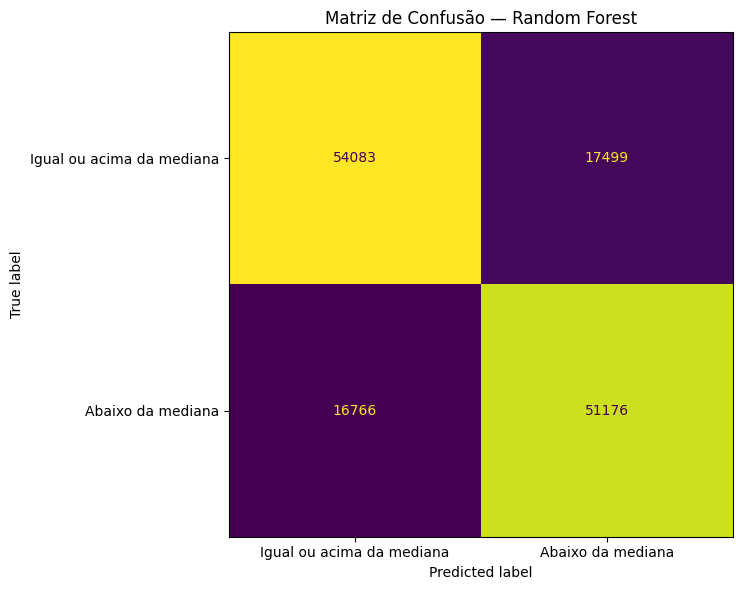

In [32]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

matriz_confusao = confusion_matrix(
    y_teste,
    previsoes_final,
    labels=[0, 1]
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

grafico_matriz = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao,
    display_labels=[
        "Igual ou acima da mediana",
        "Abaixo da mediana"
    ]
)

grafico_matriz.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

plt.title(
    "Matriz de Confusão — Random Forest"
)

plt.tight_layout()

plt.show()

A matriz de confusão mostrou que o modelo classificou corretamente 54.083 registros com desempenho igual ou acima da mediana e 51.176 registros abaixo da mediana. Também foram observados 17.499 casos classificados incorretamente como abaixo da mediana e 16.766 casos que foram classificados incorretamente como iguais ou superiores. De forma geral, o modelo apresentou desempenho semelhante nas duas classes, embora ainda tenha ocorrido uma quantidade considerável de erros.

## Curva ROC

A curva ROC permite avaliar a capacidade do modelo de diferenciar as duas classes em diferentes limites de decisão. Quanto mais próxima a curva estiver do canto superior esquerdo, melhor é a capacidade de separação do modelo.

A área sob a curva, chamada AUC, varia de 0 a 1. Valores próximos de 0,5 indicam um desempenho semelhante ao acaso, enquanto valores mais próximos de 1 representam uma melhor capacidade de distinguir as classes.

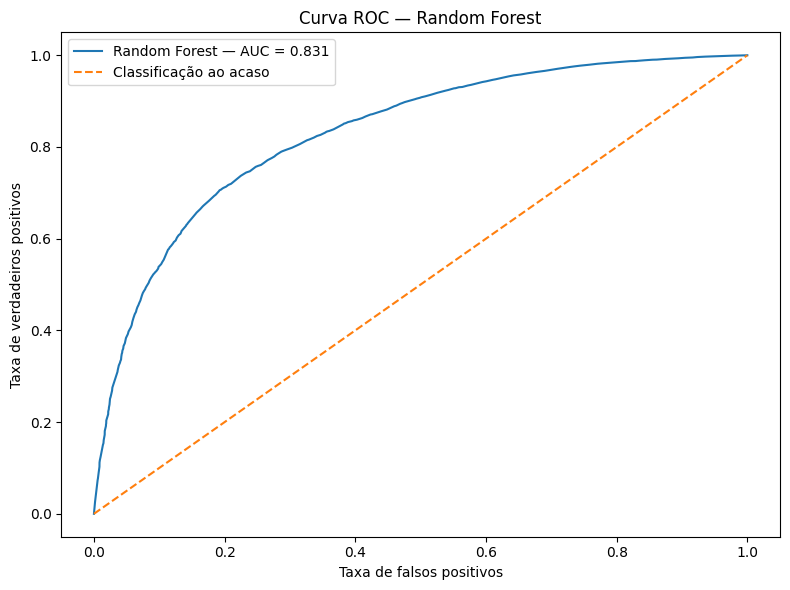

Área sob a curva ROC: 0.831


In [33]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

# Cálculo da curva ROC

taxa_falso_positivo, taxa_verdadeiro_positivo, limites = roc_curve(
    y_teste,
    probabilidades_final
)

# Cálculo da área sob a curva

auc = roc_auc_score(
    y_teste,
    probabilidades_final
)

# Criação do gráfico

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    taxa_falso_positivo,
    taxa_verdadeiro_positivo,
    label=f"Random Forest — AUC = {auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificação ao acaso"
)

plt.xlabel(
    "Taxa de falsos positivos"
)

plt.ylabel(
    "Taxa de verdadeiros positivos"
)

plt.title(
    "Curva ROC — Random Forest"
)

plt.legend()

plt.tight_layout()

plt.show()

print(
    "Área sob a curva ROC:",
    round(auc, 3)
)

### Interpretação da curva ROC

A Random Forest apresentou uma área sob a curva ROC de 0,831. Esse resultado indica que o modelo possui boa capacidade de diferenciar os registros abaixo da mediana daqueles com desempenho igual ou superior à mediana.

A curva permaneceu acima da linha que representa uma classificação ao acaso, mostrando que o modelo conseguiu identificar padrões relevantes nos dados. Embora o resultado não seja perfeito, ele demonstra uma capacidade satisfatória de separação entre as duas classes.

# Seção 4 — Análise dos erros

Nesta seção serão analisados os registros classificados incorretamente pelo modelo. O objetivo é identificar em quais etapas, disciplinas, anos e conteúdos os erros ocorreram com maior frequência.

Também serão comparados os dois tipos de erro: registros abaixo da mediana classificados como iguais ou superiores e registros iguais ou superiores classificados como abaixo da mediana.

In [34]:

analise_erros = X_teste.copy()

analise_erros["classe_real"] = y_teste

analise_erros["classe_prevista"] = previsoes_final

analise_erros["acerto_real"] = dados_modelagem.loc[
    X_teste.index,
    "acerto"
]

analise_erros["resultado"] = (
    analise_erros["classe_real"]
    ==
    analise_erros["classe_prevista"]
)

erros_modelo = analise_erros[
    analise_erros["resultado"] == False
].copy()

print(
    "Total de registros no teste:",
    analise_erros.shape[0]
)

print(
    "Quantidade de classificações corretas:",
    analise_erros["resultado"].sum()
)

print(
    "Quantidade de erros:",
    erros_modelo.shape[0]
)

print(
    "Taxa de erro:",
    round(
        erros_modelo.shape[0]
        /
        analise_erros.shape[0]
        *
        100,
        2
    ),
    "%"
)

Total de registros no teste: 139524
Quantidade de classificações corretas: 105259
Quantidade de erros: 34265
Taxa de erro: 24.56 %


## Tipos de erro encontrados

Os erros foram separados de acordo com a classe real e a classificação realizada pelo modelo. Essa divisão permite identificar se o modelo indicou uma possível necessidade de atenção quando ela não existia ou se deixou de identificar um registro que apresentava desempenho abaixo da mediana.

No contexto do estudo, o segundo caso merece maior atenção, pois representa situações em que um resultado abaixo da mediana foi classificado pelo modelo como igual ou superior.

In [35]:

erros_modelo["tipo_erro"] = "Não identificado"

erros_modelo.loc[
    (erros_modelo["classe_real"] == 0)
    &
    (erros_modelo["classe_prevista"] == 1),
    "tipo_erro"
] = "Igual ou acima classificado como abaixo"


erros_modelo.loc[
    (erros_modelo["classe_real"] == 1)
    &
    (erros_modelo["classe_prevista"] == 0),
    "tipo_erro"
] = "Abaixo classificado como igual ou acima"


tipos_erros = (
    erros_modelo["tipo_erro"]
    .value_counts()
    .rename_axis("Tipo de erro")
    .reset_index(name="Quantidade")
)

tipos_erros["Percentual dos erros (%)"] = (
    tipos_erros["Quantidade"]
    /
    tipos_erros["Quantidade"].sum()
    *
    100
).round(2)

tipos_erros

,Tipo de erro,Quantidade,Percentual dos erros (%)
0,Igual ou acima classificado como abaixo,17499,51.07
1,Abaixo classificado como igual ou acima,16766,48.93


### Interpretação dos tipos de erro

Os dois tipos de erro apresentaram quantidades próximas. Em 51,07% dos casos, registros que estavam abaixo da mediana foram classificados como iguais ou superiores. Nos outros 48,93%, registros iguais ou acima da mediana foram classificados como abaixo.

O primeiro tipo merece maior atenção, pois representa situações em que o modelo deixou de identificar um resultado que poderia indicar necessidade de acompanhamento. Mesmo assim, a diferença entre os dois tipos foi pequena, mostrando que os erros ocorreram de forma relativamente equilibrada.

## Erros por disciplina

Para verificar se o desempenho do modelo apresentou diferenças entre as disciplinas, foi calculada a quantidade de registros analisados, o número de classificações incorretas e a taxa de erro em Matemática e Língua Portuguesa.

In [36]:

erros_por_disciplina = (
    analise_erros
    .groupby("disciplina")
    .agg(
        Total_de_registros=("resultado", "size"),
        Quantidade_de_erros=(
            "resultado",
            lambda valores: (~valores).sum()
        )
    )
    .reset_index()
)

erros_por_disciplina["Taxa de erro (%)"] = (
    erros_por_disciplina["Quantidade_de_erros"]
    /
    erros_por_disciplina["Total_de_registros"]
    *
    100
).round(2)

erros_por_disciplina

,disciplina,Total_de_registros,Quantidade_de_erros,Taxa de erro (%)
0,LINGUA PORTUGUESA,48189,13383,27.77
1,MATEMATICA,91335,20882,22.86


### Interpretação dos erros por disciplina

A análise mostrou que a taxa de erro foi maior em Língua Portuguesa, com 27,77%, enquanto Matemática apresentou taxa de 22,86%.

Esse resultado indica que o modelo encontrou maior dificuldade para identificar os padrões relacionados aos conteúdos de Língua Portuguesa. Uma possível explicação é que habilidades de leitura e interpretação podem apresentar maior variação entre os descritores e os anos analisados.

## Erros por etapa de ensino

Também foi analisada a taxa de erro em cada etapa de ensino. O objetivo foi verificar se o modelo apresentou maior dificuldade nos registros do 5º ou do 9º ano do Ensino Fundamental.

In [37]:

erros_por_etapa = (
    analise_erros
    .groupby("etapa")
    .agg(
        Total_de_registros=("resultado", "size"),
        Quantidade_de_erros=(
            "resultado",
            lambda valores: (~valores).sum()
        )
    )
    .reset_index()
)

erros_por_etapa["Taxa de erro (%)"] = (
    erros_por_etapa["Quantidade_de_erros"]
    /
    erros_por_etapa["Total_de_registros"]
    *
    100
).round(2)

erros_por_etapa

,etapa,Total_de_registros,Quantidade_de_erros,Taxa de erro (%)
0,5º ANO EF,84505,21646,25.62
1,9º ANO EF,55019,12619,22.94


### Interpretação dos erros por etapa

A taxa de erro foi de 25,62% para o 5º ano e de 22,94% para o 9º ano. Apesar de os resultados serem próximos, o modelo apresentou uma dificuldade um pouco maior na classificação dos registros do 5º ano.

De forma geral, o desempenho permaneceu semelhante entre as duas etapas, sem uma diferença muito elevada na quantidade proporcional de erros.

## Erros por ano

A taxa de erro também foi analisada em cada ano disponível na base. Essa comparação permite verificar se o modelo apresentou maior dificuldade em determinados períodos.

In [38]:

erros_por_ano = (
    analise_erros
    .groupby("Ano")
    .agg(
        Total_de_registros=("resultado", "size"),
        Quantidade_de_erros=(
            "resultado",
            lambda valores: (~valores).sum()
        )
    )
    .reset_index()
)

erros_por_ano["Taxa de erro (%)"] = (
    erros_por_ano["Quantidade_de_erros"]
    /
    erros_por_ano["Total_de_registros"]
    *
    100
).round(2)

erros_por_ano

,Ano,Total_de_registros,Quantidade_de_erros,Taxa de erro (%)
0,2016,29460,7263,24.65
1,2019,25893,5627,21.73
2,2021,7058,1916,27.15
3,2022,24161,6400,26.49
4,2023,29412,7309,24.85
5,2024,23540,5750,24.43


### Interpretação dos erros por ano

A taxa de erro apresentou variações entre os anos analisados. O maior valor foi observado em 2021, com 27,15%. Já o menor percentual ocorreu em 2019, com 21,73%.

Essas diferenças mostram que o modelo apresentou maior dificuldade para identificar os padrões presentes em alguns anos. Isso pode estar relacionado a mudanças nas características dos dados, nos conteúdos avaliados ou na distribuição dos resultados ao longo do período.

In [39]:

verificacao_anos = pd.DataFrame({

    "Após filtro inicial":
    dados_filtrados["Ano"]
    .value_counts()
    .sort_index(),

    "Após seleção dos conteúdos":
    dados_conteudos["Ano"]
    .value_counts()
    .sort_index(),

    "Após limpeza do acerto":
    dados_modelagem["Ano"]
    .value_counts()
    .sort_index()

}).fillna(0).astype(int)

verificacao_anos

,Após filtro inicial,Após seleção dos conteúdos,Após limpeza do acerto
Ano,,,
2016,573496,159852,146967
2019,512703,141601,128527
2021,231873,59396,35440
2022,493236,135523,121067
2023,539162,165254,146903
2024,502827,171948,118713


### Disponibilidade dos dados após os filtros

As bases de 2015 e 2017 foram carregadas durante a preparação dos dados. Entretanto, após a aplicação dos filtros definidos para o estudo, não permaneceram registros desses anos.

Dessa forma, a etapa de modelagem utilizou dados referentes aos anos de 2016, 2019, 2021, 2022, 2023 e 2024. Essa diferença ocorreu devido às características e à disponibilidade dos registros em cada edição das avaliações.

## Conteúdos com maior taxa de erro

Por fim, foram analisados os conteúdos em que o modelo apresentou maior dificuldade. Para evitar conclusões baseadas em poucos registros, foram considerados apenas os conteúdos com pelo menos 200 observações no conjunto de teste.

In [40]:

analise_erros["conteudo"] = dados_modelagem.loc[
    X_teste.index,
    "descritor_descricao"
]

erros_por_conteudo = (
    analise_erros
    .groupby(
        [
            "disciplina",
            "descricao_padronizada"
        ]
    )
    .agg(
        Conteudo=(
            "conteudo",
            "first"
        ),
        
        Total_de_registros=(
            "resultado",
            "size"
        ),
        
        Quantidade_de_erros=(
            "resultado",
            lambda valores: (~valores).sum()
        )
    )
    .reset_index()
)

erros_por_conteudo["Taxa de erro (%)"] = (
    erros_por_conteudo["Quantidade_de_erros"]
    /
    erros_por_conteudo["Total_de_registros"]
    *
    100
).round(2)

conteudos_maior_erro = (
    erros_por_conteudo[
        erros_por_conteudo["Total_de_registros"] >= 200
    ]
    .sort_values(
        "Taxa de erro (%)",
        ascending=False
    )
    .head(10)
    [
        [
            "disciplina",
            "Conteudo",
            "Total_de_registros",
            "Quantidade_de_erros",
            "Taxa de erro (%)"
        ]
    ]
    .reset_index(drop=True)
)

conteudos_maior_erro

,disciplina,Conteudo,Total_de_registros,Quantidade_de_erros,Taxa de erro (%)
0,MATEMATICA,Associar informações apresentadas em listas e/ou tabelas simples aos gráficos que as representam e vice-versa.,596,284,47.65
1,MATEMATICA,"Efetuar cálculos com números inteiros, envolvendo as operações (adição, subtração, multiplicação, divisão, potenciação).",594,282,47.47
2,MATEMATICA,"Resolver problema com números racionais envolvendo as operações (adição, subtração, multiplicação, divisão, potenciação).",639,293,45.85
3,MATEMATICA,UTILIZAR NUMEROS RACIONAIS ENVOLVENDO DIFERENTES SIGNIFICADOS DAS OPERACOES NA RESOLUCAO DE PROBLEMAS,3360,1435,42.71
4,LINGUA PORTUGUESA,Distinguir um fato da opinião relativa a esse fato.,1404,596,42.45
5,MATEMATICA,IDENTIFICAR FRACAO COMO REPRESENTACAO QUE PODE ESTAR ASSOCIADA A DIFERENTES SIGNIFICADOS,1128,470,41.67
6,MATEMATICA,Identificar a localização de números racionais representados na forma decimal na reta numérica.,776,317,40.85
7,MATEMATICA,Identificar a localização de números racionais na reta numérica.,625,253,40.48
8,LINGUA PORTUGUESA,Inferir uma informação implícita em um texto.,1441,555,38.51
9,MATEMATICA,UTILIZAR NUMEROS RACIONAIS EXPRESSOS NA FORMA DECIMAL ENVOLVENDO MULTIPLICACAO OU DIVISAO NA RESOLUCAO DE PROBLEMAS,4982,1889,37.92


### Interpretação dos erros por conteúdo

Dos 5 conteúdos com maior taxa de erro, 4 são de Matemática. Incluindo o conteúdo com maior taxa de erro, “Associar informações apresentadas em listas e/ou tabelas simples aos gráficos que as representam e vice-versa.”, com 47,65%. Além desse, na disciplina, destacaram-se conteúdos envolvendo frações, multiplicação, divisão e números racionais.

Esses resultados indicam que o modelo apresentou maior dificuldade para classificar registros relacionados a essas habilidades. No entanto, isso não significa, necessariamente, que esses foram os conteúdos com menor desempenho dos estudantes, mas sim que os padrões disponíveis nos dados foram menos claros para o modelo.

# Seção 5 — Limitações

Apesar dos resultados obtidos, o modelo apresenta algumas limitações. A classificação foi criada utilizando a mediana do percentual de acerto, igual a 57%, como ponto de separação entre as classes. Esse valor foi utilizado como critério estatístico e não representa uma classificação pedagógica oficial.

O modelo utilizou apenas as informações disponíveis nas bases analisadas, como ano, etapa, disciplina e conteúdo avaliado. Outros fatores que podem influenciar o desempenho dos estudantes, como frequência escolar, condições socioeconômicas, infraestrutura da escola, formação dos professores e participação dos alunos, não estavam disponíveis.

Também foram removidos registros sem percentual de acerto válido, incluindo os códigos BP, NP e NP/BP. Além disso, após a aplicação dos filtros definidos para o estudo, as bases de 2015 e 2017 não permaneceram na etapa de modelagem.

Por fim, o modelo apresentou desempenho satisfatório, mas ainda realizou classificações incorretas em parte dos registros. Dessa forma, seus resultados devem ser utilizados como apoio à análise e à tomada de decisão, não substituindo a avaliação realizada por profissionais da área educacional.